In [2]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# CLASSICAL ALGORITHMS

In [3]:
# Searches through an unordered list one by one
def classical_linear_search(items, target):
    queries = 0
    for item in items:
        queries += 1
        if item == target:
            return queries, item
        
    return queries, None

In [4]:
# Searches through a sorted list using binary search
def classical_binary_search(items, target):
    low, high = 0, len(items) - 1
    queries = 0
    while low <= high:
        queries += 1
        mid = (low + high) // 2
        if items[mid] == target:
            return queries, items[mid]
        elif items[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
            
    return queries, None

# QUANTUM ALGORITHM (Grover)

In [5]:
# Oracle that marks the target state by flipping its phase.
# Uses a multi-controlled Z gate.
def grover_oracle(n_qubits, target):
    qc = QuantumCircuit(n_qubits, name='oracle')
    
    # Flip qubits where target bit is 0 (so all-ones = target)
    target_bits = format(target, f'0{n_qubits}b')       # format(5, '03b') = "101"
    for i, bit in enumerate(reversed(target_bits)):     # reversed becuase the qubit 0 is the less significant
        if bit == '0':
            qc.x(i)
    
    # Multi-controlled Z
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)     # Generalized Toffoli
    qc.h(n_qubits - 1)
    
    # Undo the flips
    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            qc.x(i)

    return qc

In [6]:
# Grover diffusion operator (reflection about the mean).
def grover_reflection(n_qubits):
    qc = QuantumCircuit(n_qubits, name='reflection')
    qc.h(range(n_qubits))                               # Only rest the target state with all 0's
    qc.x(range(n_qubits))                               # Flips the bits so the target state becomes all 1's
    qc.h(n_qubits - 1)                                  # 
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)     # Applies a -1 phase to the all-ones state so now is positive (- * - = +)
    qc.h(n_qubits - 1)                                  #
    qc.x(range(n_qubits))                               # Undo the flips so the target state becomes all 0's again
    qc.h(range(n_qubits))                               # Undo the initial Hadamards but now the target state has major probability 
    return qc

In [7]:
# Full Grover circuit for n_qubits searching for target.
# Returns the most measured state and its probability.
def grover_search(n_qubits, target, shots=1000):
    N = 2 ** n_qubits

    # Optimal number of iterations: π/4 * √N
    n_iterations = max(1, int(np.pi / 4 * np.sqrt(N)))

    oracle = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)

    # Build circuit
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))                               # Initial superposition

    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))

    # Run
    backend = AerSimulator()
    transpiled = transpile(qc, backend)

    start_time = time.perf_counter()
    job = backend.run(transpiled, shots=shots)
    counts = job.result().get_counts()
    total_time = time.perf_counter() - start_time

    # Most frequent result
    target_str = format(target, f'0{n_qubits}b')
    found = target_str in counts and counts[target_str] == max(counts.values())

    return n_iterations, counts, found, total_time

# DRAW CIRCUITS (printed once before the comparison loop)

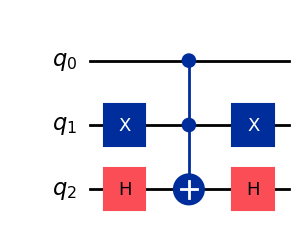

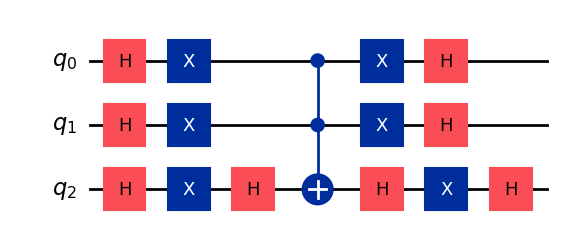

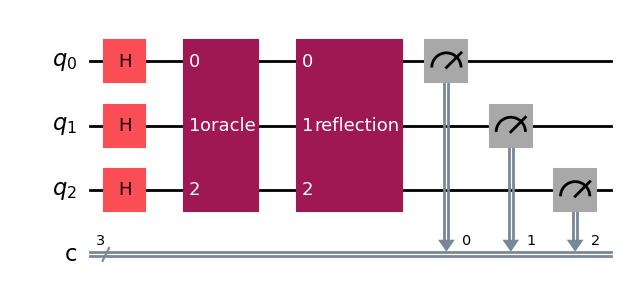

In [8]:
n_example = 3
target_example = 5

oracle_example = grover_oracle(n_example, target_example)
display(oracle_example.draw(output='mpl'))

reflection_example = grover_reflection(n_example)
display(reflection_example.draw(output='mpl'))

qc_example = QuantumCircuit(n_example, n_example)
qc_example.h(range(n_example))
qc_example.append(oracle_example, range(n_example))
qc_example.append(reflection_example, range(n_example))
qc_example.measure(range(n_example), range(n_example))
display(qc_example.draw(output='mpl'))

# RUN COMPARISON

In [ ]:
qubit_range = range(2, 12)
results = {
    'n_qubits':         [],
    'N':                [],
    'linear_queries':   [],
    'binary_queries':   [],
    'grover_iters':     [],
    'linear_time':      [],
    'binary_time':      [],
    'grover_time':      [],
    'grover_correct':   [],
}

RUNS = 10  # Average over this many runs per size

for n in qubit_range:
    N = 2 ** n
    target = random.randint(0, N - 1)
    items_unordered = list(range(N))
    random.shuffle(items_unordered)
    items_ordered = sorted(items_unordered)

    print(f"n={n}, N={N}, target={target}")

    # Linear search 
    lin_queries_total = 0
    lin_time_total = 0
    for _ in range(RUNS):
        random.shuffle(items_unordered)
        start = time.perf_counter()
        queries, _ = classical_linear_search(items_unordered, target)
        lin_time_total += time.perf_counter() - start
        lin_queries_total += queries

    # Binary search 
    bin_queries_total = 0
    bin_time_total = 0
    for _ in range(RUNS):
        start = time.perf_counter()
        queries, _ = classical_binary_search(items_ordered, target)
        bin_time_total += time.perf_counter() - start
        bin_queries_total += queries

    # Grover
    n_iters, counts, correct, g_time = grover_search(n, target, shots=1000)

    results['n_qubits'].append(n)
    results['N'].append(N)
    results['linear_queries'].append(lin_queries_total / RUNS)
    results['binary_queries'].append(bin_queries_total / RUNS)
    results['grover_iters'].append(n_iters)
    results['linear_time'].append(lin_time_total / RUNS)
    results['binary_time'].append(bin_time_total / RUNS)
    results['grover_time'].append(g_time)
    results['grover_correct'].append(correct)

n=2, N=4, target=3
n=3, N=8, target=5
n=4, N=16, target=15
n=5, N=32, target=5
n=6, N=64, target=60
n=7, N=128, target=11
n=8, N=256, target=221
n=9, N=512, target=497
n=10, N=1024, target=72
n=11, N=2048, target=856


# PLOT 1 — Queries / Iterations

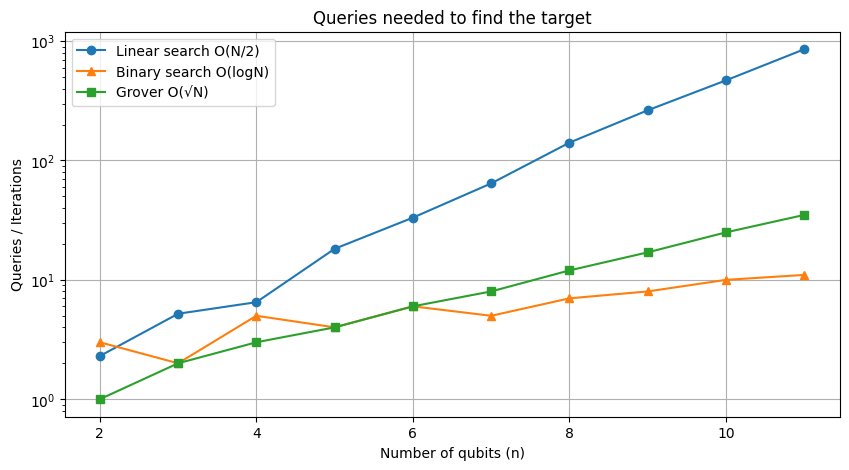

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], results['linear_queries'],  'o-', label='Linear search O(N/2)')
plt.plot(results['n_qubits'], results['binary_queries'],  '^-', label='Binary search O(logN)')
plt.plot(results['n_qubits'], results['grover_iters'],    's-', label='Grover O(√N)')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Queries / Iterations')
plt.title('Queries needed to find the target')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

# PLOT 2 — Actual execution time

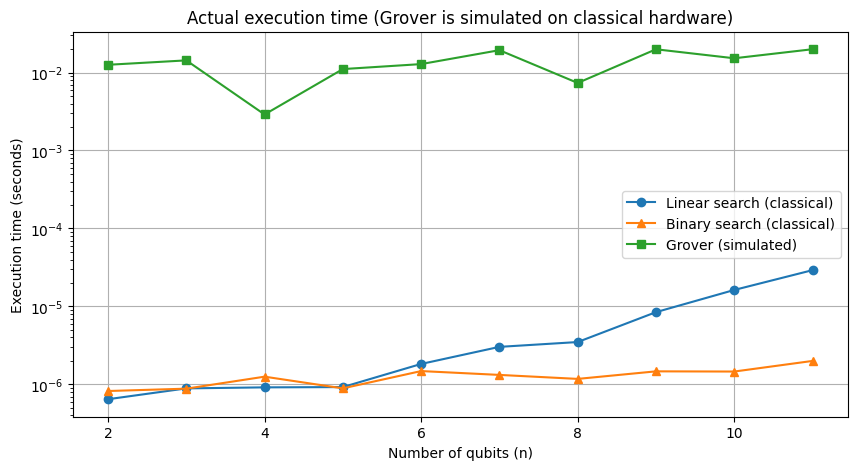

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], results['linear_time'],  'o-', label='Linear search (classical)')
plt.plot(results['n_qubits'], results['binary_time'],  '^-', label='Binary search (classical)')
plt.plot(results['n_qubits'], results['grover_time'],  's-', label='Grover (simulated)')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Execution time (seconds)')
plt.title('Actual execution time (Grover is simulated on classical hardware)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

# PRINT SUMMARY

In [17]:
print(f"\n{'n':>4} {'N':>6} {'Linear':>8} {'Binary':>8} {'Grover':>8} {'Correct':>8}")
print("-" * 50)
for i in range(len(results['n_qubits'])):
    print(f"{results['n_qubits'][i]:>4} "
          f"{results['N'][i]:>6} "
          f"{results['linear_queries'][i]:>8.1f} "
          f"{results['binary_queries'][i]:>8.1f} "
          f"{results['grover_iters'][i]:>8} "
          f"{'Yes' if results['grover_correct'][i] else 'No':>8}")


   n      N   Linear   Binary   Grover  Correct
--------------------------------------------------
   2      4      2.3      3.0        1      Yes
   3      8      5.2      2.0        2      Yes
   4     16      6.5      5.0        3      Yes
   5     32     18.2      4.0        4      Yes
   6     64     33.2      6.0        6      Yes
   7    128     64.3      5.0        8      Yes
   8    256    141.1      7.0       12      Yes
   9    512    263.4      8.0       17      Yes
  10   1024    469.2     10.0       25      Yes
  11   2048    854.8     11.0       35      Yes
